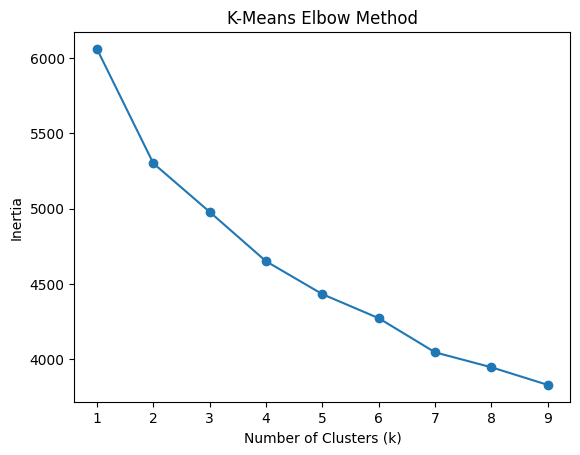

Cluster counts:
 kmeans_cluster
1    154
0    149
Name: count, dtype: int64

Comparison with target:
 target            0    1
kmeans_cluster          
0                35  114
1               129   25


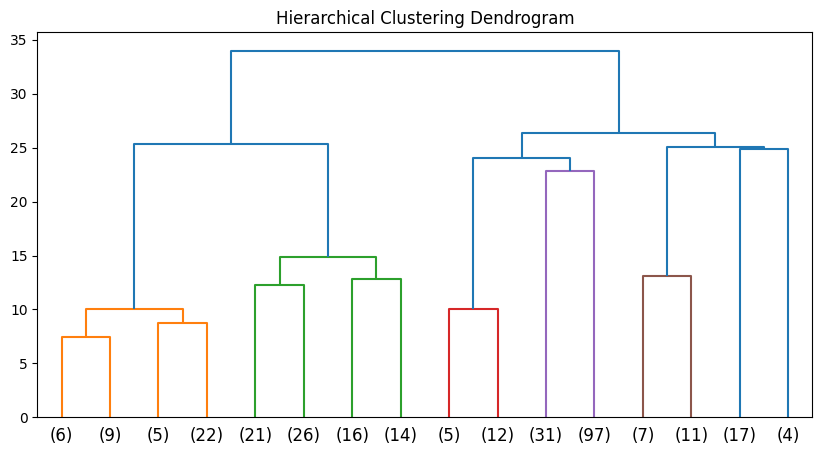


Comparison with target (Hierarchical):
 target          0    1
hier_cluster          
0              64  120
1             100   19


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset
df = pd.read_csv("../data/heart_disease_cleaned.csv")
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

X = df.drop("target", axis=1)
y = df["target"]

# ===============================
# 1. K-Means Clustering
# ===============================
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.show()

# Choose k=2 (since target is binary)
kmeans = KMeans(n_clusters=2, random_state=42)
df["kmeans_cluster"] = kmeans.fit_predict(X)

print("Cluster counts:\n", df["kmeans_cluster"].value_counts())
print("\nComparison with target:\n", pd.crosstab(df["kmeans_cluster"], y))

# ===============================
# 2. Hierarchical Clustering
# ===============================
linked = linkage(X, 'ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=3)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

hc = AgglomerativeClustering(n_clusters=2)
df["hier_cluster"] = hc.fit_predict(X)

print("\nComparison with target (Hierarchical):\n", pd.crosstab(df["hier_cluster"], y))